In [1]:
import json
import re
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from wordcloud import WordCloud
from collections import Counter
from collections import defaultdict
import numpy as np
import nltk
from nltk.corpus import stopwords
from pathlib import Path
import spacy

nlp = spacy.load("en_core_web_sm")

In [2]:
data_folder = "../../datasets/interxmo_processed"
npy_files_p1 = glob(f"{data_folder}/motion_processed/person1/*.npy")
npy_files_p2 = glob(f"{data_folder}/motion_processed/person2/*.npy")
txt_files = glob(f"{data_folder}/annots/*.txt")

In [3]:
total_T_p1 = 0
total_T_p2 = 0

for f in npy_files_p1:
    arr = np.load(f)
    if arr.ndim == 2 and arr.shape[1] == 262:
        total_T_p1 += arr.shape[0]

for f in npy_files_p2:
    arr = np.load(f)
    if arr.ndim == 2 and arr.shape[1] == 262:
        total_T_p2 += arr.shape[0]

print(
    "Person 1: Total number of frames:", total_T_p1, "for", len(npy_files_p1), "files"
)
print(
    "Person 2: Total number of frames:", total_T_p2, "for", len(npy_files_p2), "files"
)
print("Mean frame number per file: ", total_T_p1 / len(npy_files_p1))
print("Mean frame number per file: ", total_T_p2 / len(npy_files_p2))

print(
    "This means a total of:",
    total_T_p2,"frames =",total_T_p2/30,"s =",total_T_p2/60,"min",total_T_p2/30/60/60,"h"
)

Person 1: Total number of frames: 3435442 for 17796 files
Person 2: Total number of frames: 3435442 for 17796 files
Mean frame number per file:  193.04574061586874
Mean frame number per file:  193.04574061586874
This means a total of: 3435442 frames = 114514.73333333334 s = 57257.36666666667 min 31.80964814814815 h


In [4]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))


def extract_words(text):
    if not text:  # skip None or empty string
        return []
    return [
        w
        for w in re.findall(r"\b\w+\b", text.lower())
        if w not in stop_words and len(w) > 1
    ]

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/natsalaz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


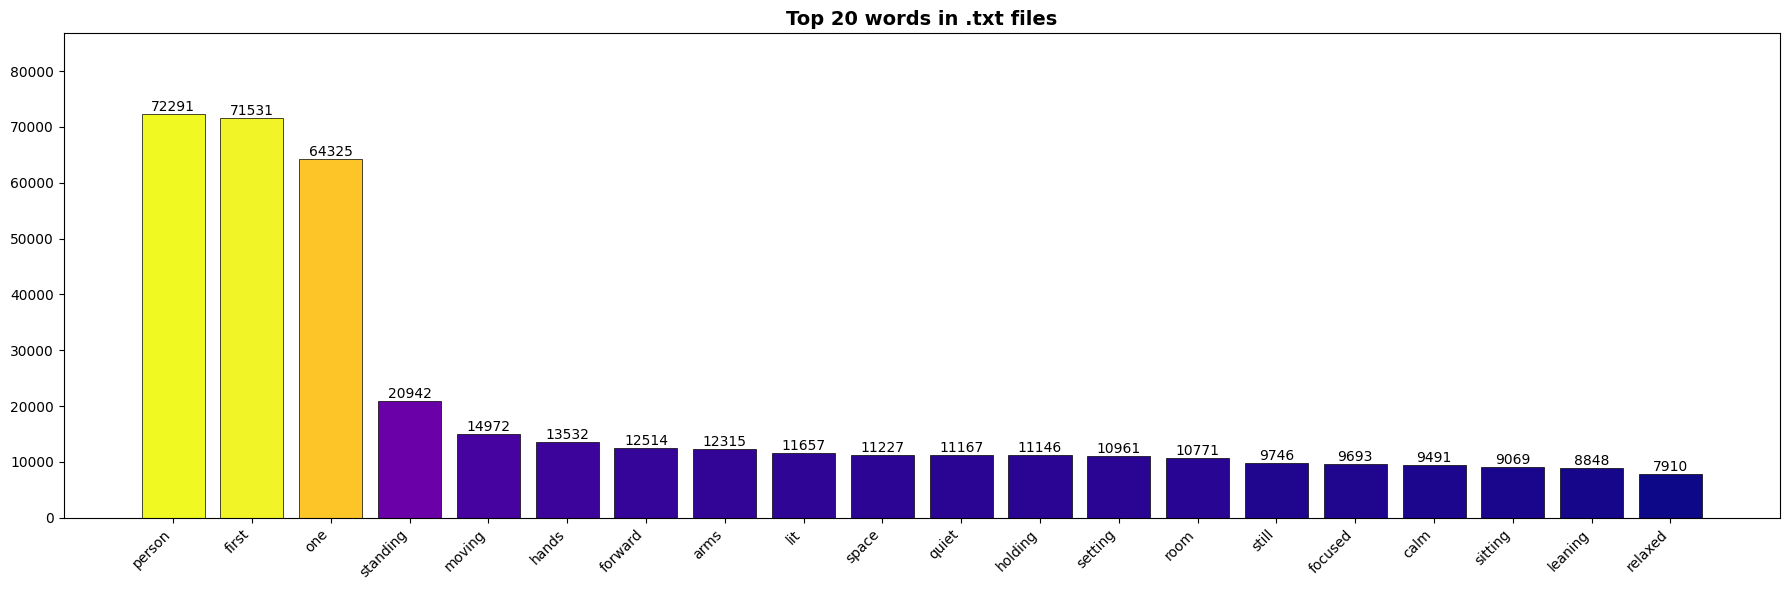

In [5]:
txt_words = []
for txt in txt_files:
    with open(txt, "r") as f:
        for line in f:
            txt_words.extend(extract_words(line))

if txt_words:
    txt_counts = Counter(txt_words).most_common(20)
    txt_labels, txt_vals = zip(*txt_counts)

    fig, ax = plt.subplots(1, 1, figsize=(18, 6))
    plt.style.use("ggplot")

    def plot_pretty_bar(ax, labels, values, title, cmap_name="viridis"):
        import matplotlib.colors as mcolors

        cmap = plt.colormaps[cmap_name]
        norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
        colors = [cmap(norm(val)) for val in values]
        x = range(len(labels))
        bars = ax.bar(x, values, color=colors, edgecolor="black")
        ax.set_title(title, fontsize=14, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
        ax.tick_params(axis="y", labelsize=10)
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.5,
                str(height),
                ha="center",
                va="bottom",
                fontsize=10,
            )
        ax.set_ylim(0, max(values) * 1.2)

    plot_pretty_bar(
        ax, txt_labels, txt_vals, "Top 20 words in .txt files", cmap_name="plasma"
    )
    plt.tight_layout()
    plt.show()

else:
    print("No words found in .txt files.")

In [6]:
def extract_verbs_from_list(words):
    text = " ".join(words)
    doc = nlp(text)
    return [token.text for token in doc if token.pos_ == "VERB"]

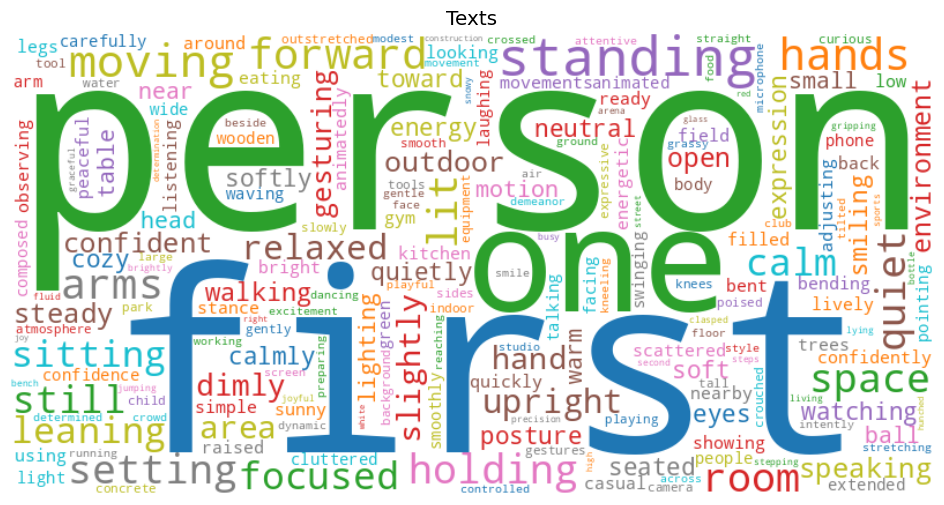

ValueError: [E088] Text of length 8020431 exceeds maximum of 1000000. The parser and NER models require roughly 1GB of temporary memory per 100,000 characters in the input. This means long texts may cause memory allocation errors. If you're not using the parser or NER, it's probably safe to increase the `nlp.max_length` limit. The limit is in number of characters, so you can check whether your inputs are too long by checking `len(text)`.

In [7]:
def show_wc(word_list, title, cmap):
    wc = WordCloud(width=800, height=400, background_color="white", colormap=cmap)
    wc.generate_from_frequencies(Counter(word_list))
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

show_wc(txt_words, "Texts", "tab10")
show_wc(extract_verbs_from_list(txt_words), "Verbs only", "tab10")

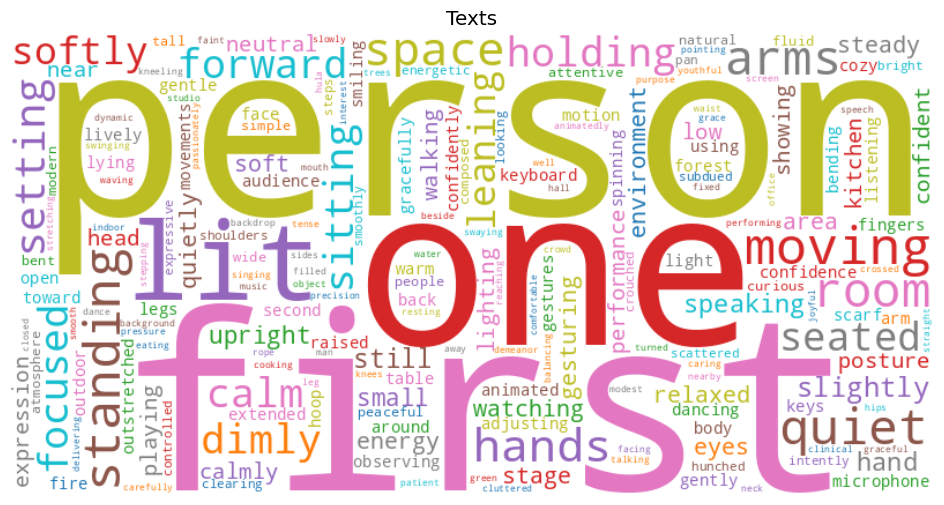

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x745d3c3de820>>
Traceback (most recent call last):
  File "/home/natsalaz/anaconda3/envs/emage/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


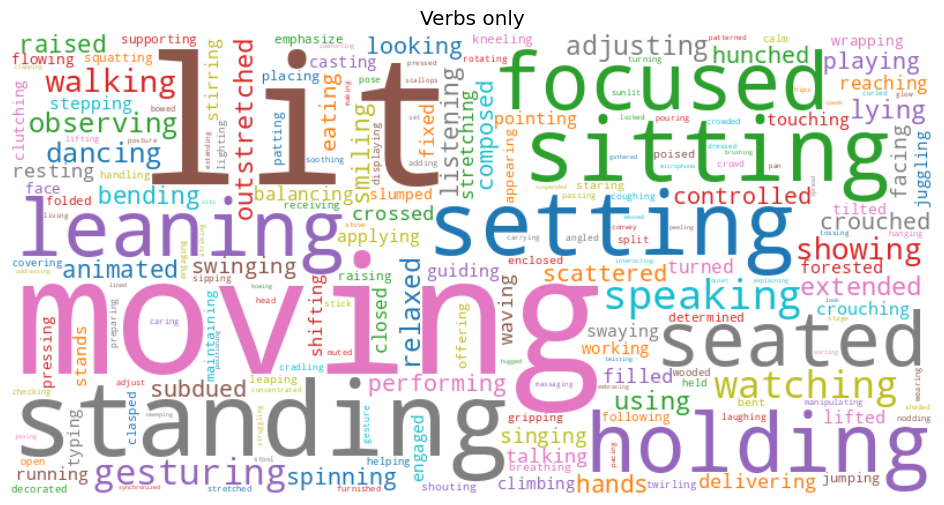

In [ ]:
def show_wc(word_list, title, cmap):
    wc = WordCloud(width=800, height=400, background_color="white", colormap=cmap)
    wc.generate_from_frequencies(Counter(word_list))
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

show_wc(txt_words, "Texts", "tab10")
show_wc(extract_verbs_from_list(txt_words), "Verbs only", "tab10")

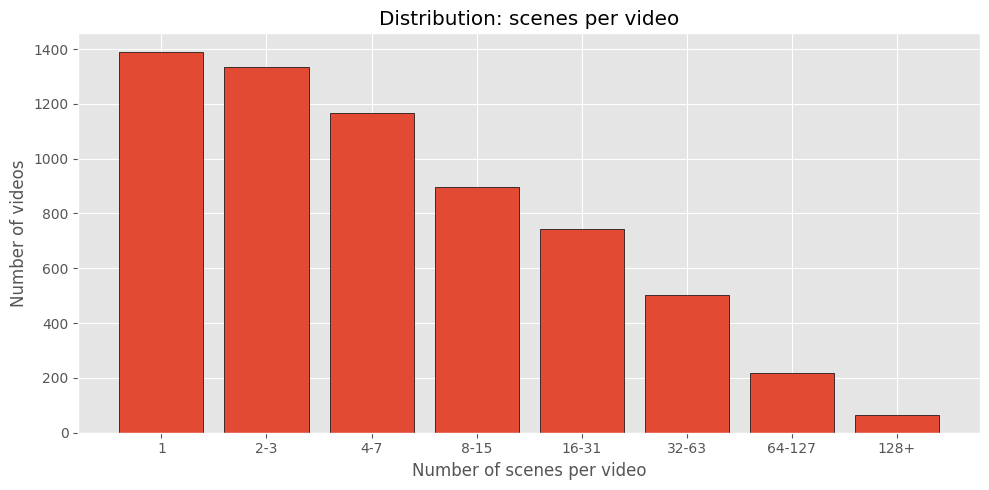
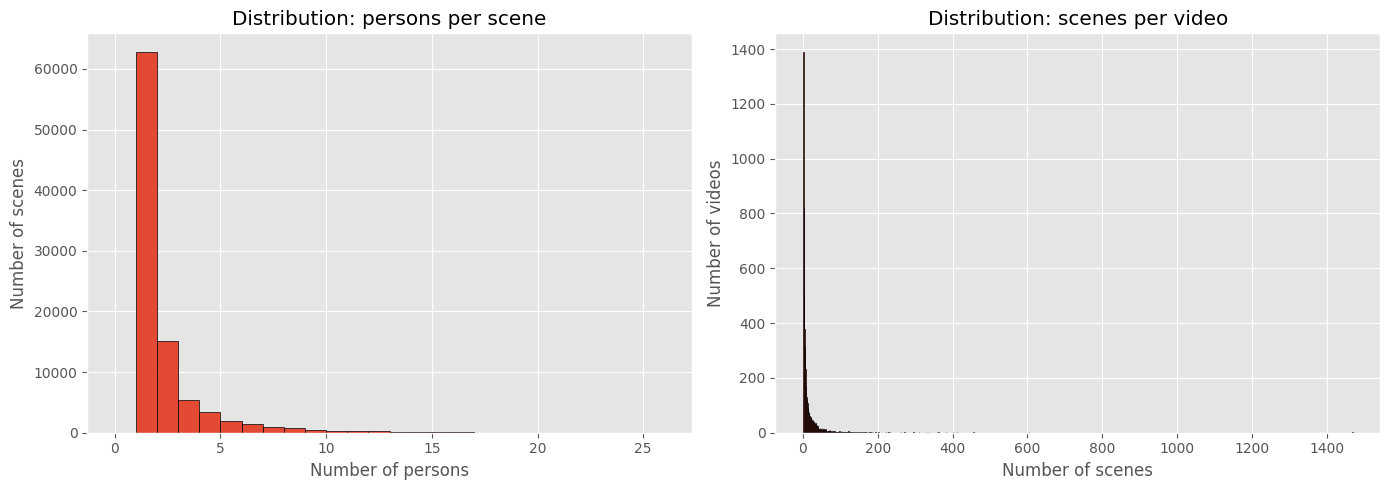